In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# from category_encoders import OneHotEncoder
from category_encoders import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, recall_score, precision_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline

In [2]:
features = [ 
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", 
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"
]

ordinal = ["slope", "ca"]
norminal = ["sex", "thal", "cp", "restecg", "exang"]

In [3]:
def wrangle_data(filepath):
    df = pd.read_csv(filepath)
    df.columns = features
    for ordi in ordinal:
        df[ordi] = pd.to_numeric(df[ordi], errors="coerce")
    
    #use the original value of cp, restecg and thal
    df["cp"] = df["cp"].replace({1: "typical_angina", 2: "atypical_angina", 3: "non_angina", 4: "asymptomatic"})
    df["thal"] = df["thal"].replace({"3.0": "normal", "6.0": "fixed_defect", "7.0": "reversible_defect", "?": "normal"})
    df["restecg"] = df["restecg"].replace({0: "normal", 1: "abnormal", 2: "probably"})
    
    #Convert and clean the ca features
    df["ca"] = df["ca"].replace("?", "0").fillna(0.0).astype(int)
    
    #Convert neccesary columns to int
    discrete_value = ["age", "sex", "fbs", "exang", "trestbps", "thalach", "slope", "chol"]
    df[discrete_value] = df[discrete_value].astype(int)
    
    #Change the target variable to binary
    df["num"] = (df["num"] > 0).astype(int)
    
    return df

In [4]:
clev = wrangle_data("heart+disease/cleveland.csv")
clev.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,67,1,asymptomatic,160,286,0,probably,108,1,1.5,2,3,normal,1
1,67,1,asymptomatic,120,229,0,probably,129,1,2.6,2,2,reversible_defect,1
2,37,1,non_angina,130,250,0,normal,187,0,3.5,3,0,normal,0
3,41,0,atypical_angina,130,204,0,probably,172,0,1.4,1,0,normal,0
4,56,1,atypical_angina,120,236,0,normal,178,0,0.8,1,0,normal,0


In [5]:
#split 
target = "num"
X = clev.drop(columns=target)
y = clev[target]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (241, 13)
y_train shape: (241,)
X_test shape: (61, 13)
y_test shape: (61,)


In [7]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_val.shape)
print("y_test shape:", y_val.shape)

X_train shape: (180, 13)
y_train shape: (180,)
X_test shape: (61, 13)
y_test shape: (61,)


In [8]:
depth_hyperparams = range(1, 50, 2)

In [10]:
# Create empty lists for training and validation accuracy scores
training_acc = []
validation_acc = []

for d in depth_hyperparams:
    # Create model with `max_depth` of `d`
    test_model = make_pipeline(
        #OneHotEncoder(use_cat_names=True),
        OrdinalEncoder(),
        DecisionTreeClassifier(max_depth=d, random_state=42)
    )
    # Fit model to training data
    test_model.fit(X_train, y_train)
    # Calculate training accuracy score and append to `training_acc`
    training_acc.append(test_model.score(X_train, y_train))
    # Calculate validation accuracy score and append to `training_acc`
    validation_acc.append(test_model.score(X_val, y_val))

print("Training Accuracy Scores:", training_acc[:3])
print("Validation Accuracy Scores:", validation_acc[:3])

Training Accuracy Scores: [0.7777777777777778, 0.8666666666666667, 0.9388888888888889]
Validation Accuracy Scores: [0.6721311475409836, 0.7049180327868853, 0.639344262295082]


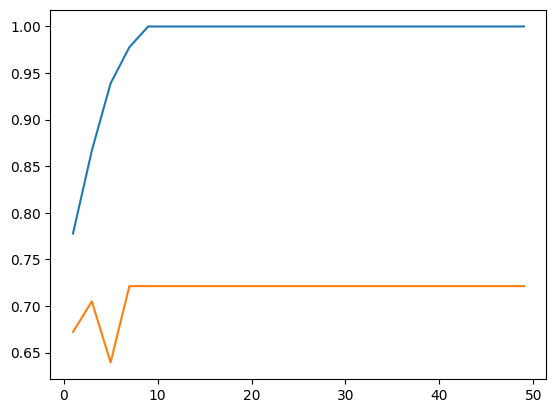

In [11]:
#Plot score
plt.plot(depth_hyperparams, training_acc, label="Training")
plt.plot(depth_hyperparams, validation_acc, label="Validate")

In [ ]:
#Using GridSerch
# params = {
#     "strategy": ["mean", "media"] # Inase of pipeline used classifier name __hyperparameter e.g randomforest__strategy:
#     "n_estimators": range(25, 100, 25),
#     "max_depth" range(10, 50, 10)
# }

# model = GridSearchCV(
#     clf # the classifer
#     param_grids# Hyperparaemter set up
#     cv # cross validation set up mostly 5
#     n_jobs # -1 run in parallel
#     verbose # 1 giver all details
# )